# PSD Resolution Estimation

Workflow:
1. **Config** — path, voxel size, optional tilt-axis override
2. **Load + analyse** — `compute_psd_analysis` auto-detects which axis is the tilt/Z
3. **Inspect** — real-space slices + PSD planes
4. **Fit** — Lorentzian fit per axis → resolution in nm

## 0 — Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path
from tifffile import imread

try:
    from DL_etomo.psd_resolution import (
        compute_psd_analysis, plot_real_space, plot_psd_planes,
        fit_lorentz_cutoff, plot_lorentz_fit, lorentz_psd_C,
    )
except ImportError:
    from DL_etomo.Src.psd_resolution import (
        compute_psd_analysis, plot_real_space, plot_psd_planes,
        fit_lorentz_cutoff, plot_lorentz_fit, lorentz_psd_C,
    )

CMAP = LinearSegmentedColormap.from_list("magenta", [(0, 0, 0), (1, 0, 1)], N=256)

## 1 — Configuration

In [2]:
DATA_DIR  = Path("../Data/PSD_test")
TIFF_PATH = DATA_DIR / "sirt1_30_2.tif"
VOXEL_NM  = 0.4        # nm  (scalar → isotropic; or (dz, dy, dx) tuple)
LABEL     = TIFF_PATH.stem

# Force tilt axis if auto-detection is unreliable (e.g. no missing wedge).
# Set to the array dimension (0, 1, or 2) that is the tilt axis, or None for auto.
TILT_AXIS = None

# PSD analysis parameters
PSD_PARAMS = dict(
    band       = 0.025,
    tail_frac  = 0.20,
    smooth_w   = 4,
    k_min_frac = 0.01,
    noise_mode = "p80",
    tol_factor = 1.0,
    debug      = True,
)

## 2 — Load + PSD analysis

In [3]:
vol = imread(str(TIFF_PATH)).astype(np.float32)
vol = np.clip(np.nan_to_num(vol), 0, None)
print(f"Loaded : {TIFF_PATH.name}  shape={vol.shape}  range=[{vol.min():.3g}, {vol.max():.3g}]")

# compute_psd_analysis auto-detects which array dim is the tilt axis,
# reorders vol → (Z=tilt, Y, X), and computes PSD + 1D profiles.
out = compute_psd_analysis(vol, voxel_nm=VOXEL_NM, tilt_axis=TILT_AXIS, **PSD_PARAMS)

print(f"\nVolume (Z,Y,X): {out['vol_shape']}  perm={out['perm']}")
print(f"Decay rates: ", {k: f"{v:.3e}" for k, v in out['decay_rates'].items()})
nyq = out["axes"]["nyquist"]
print(f"Nyquist: kx={nyq[0]:.3f}  ky={nyq[1]:.3f}  kz={nyq[2]:.3f} nm⁻¹")

Loaded : sirt1_30_2.tif  shape=(160, 160, 160)  range=[0, 34.2]

[AXIS DETECTION]
  kx: decay=1.312e+01 ← tilt (Z)
  ky: decay=9.233e+00
  kz: decay=9.453e+00
  permutation [2, 1, 0]: raw dims → (Z, Y, X)

Volume (Z,Y,X): (160, 160, 160)  perm=[2, 1, 0]
Decay rates:  {'kx': '1.312e+01', 'ky': '9.233e+00', 'kz': '9.453e+00'}
Nyquist: kx=1.250  ky=1.250  kz=1.250 nm⁻¹


## 3 — Inspect: real-space slices + PSD planes

The **XZ and YZ** slices (middle column/right) should show elongation along Z if there is a missing wedge.  
In the PSD planes, the MW gap is visible along **kz**.  
If the wrong axis is selected, set `TILT_AXIS` in the config cell.

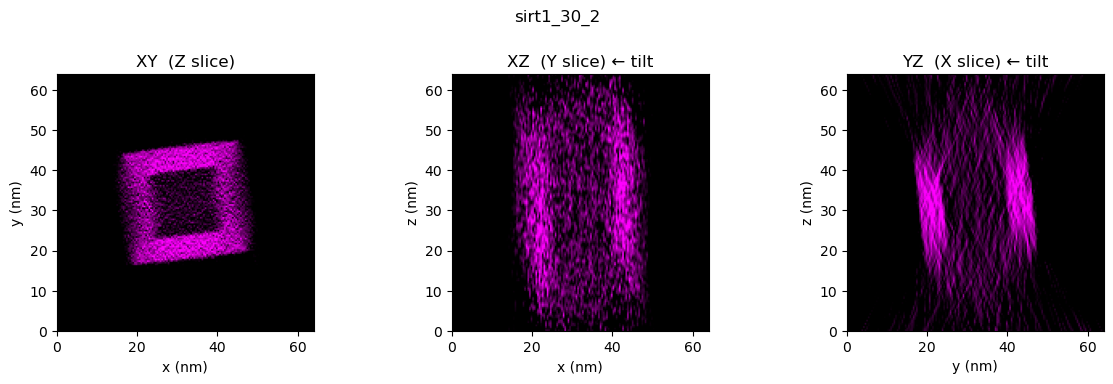

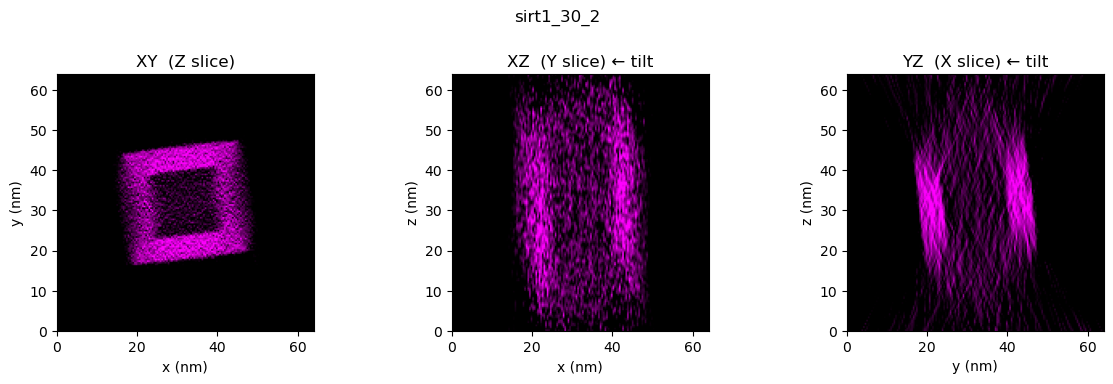

In [4]:
plot_real_space(out, cmap=CMAP, title=LABEL)

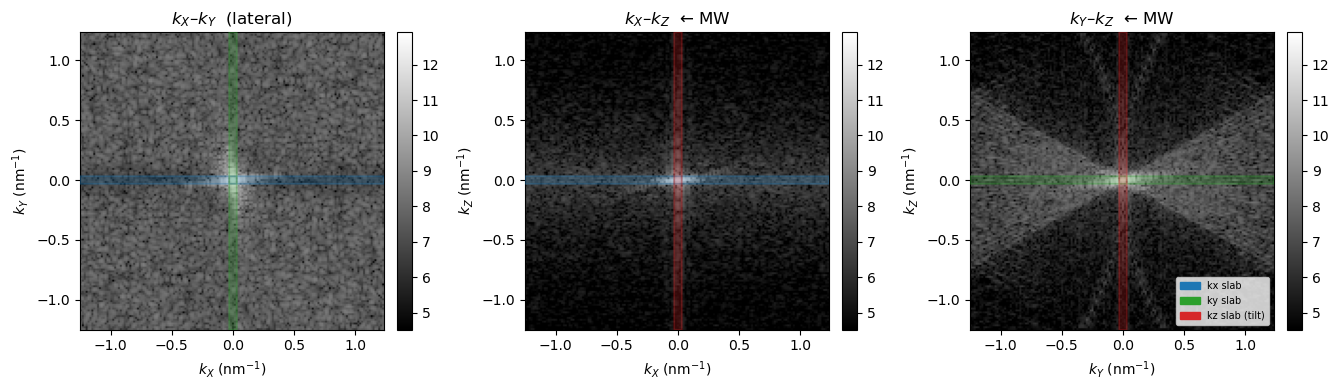

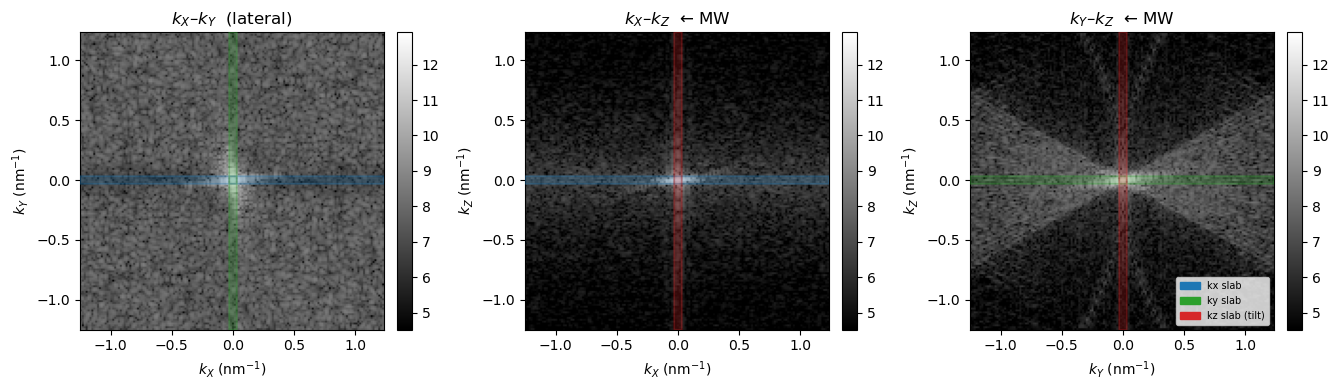

In [5]:
plot_psd_planes(out, show_bands=True)

## 4 — Resolution fitting (Lorentzian)

`kz` is always the tilt axis after `compute_psd_analysis`.
Tune `kmax_frac` and `noise_tail_frac` if the fit looks off.

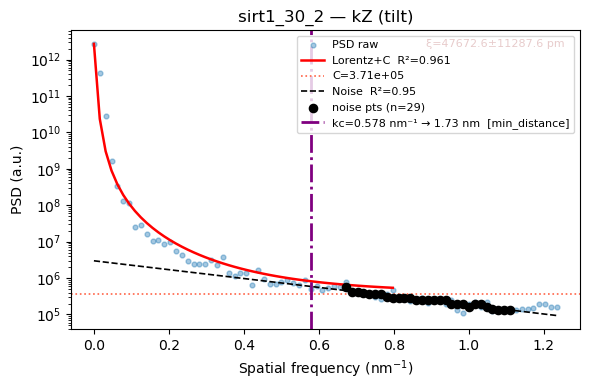

kz [min_distance]  kc=0.5781 nm⁻¹  →  1.73 nm


In [6]:
# ── kz  (tilt / missing-wedge axis — always kz after compute_psd_analysis) ──
d_kz  = out["axis_1d"]["kz"]
fit_kz = fit_lorentz_cutoff(d_kz["k"], d_kz["smooth"],
                             kmax_frac=0.65, noise_tail_frac=0.4,noise_kmax_frac=.9, choose_cut="last")
plot_lorentz_fit(out, "kz", fit_kz, title=f"{LABEL} — kZ (tilt)")
if fit_kz["ok"]:
    print(f"kz [{fit_kz['cut_mode']}]  kc={fit_kz['k_cut']:.4f} nm⁻¹  →  {fit_kz['res_cut_nm']:.2f} nm")

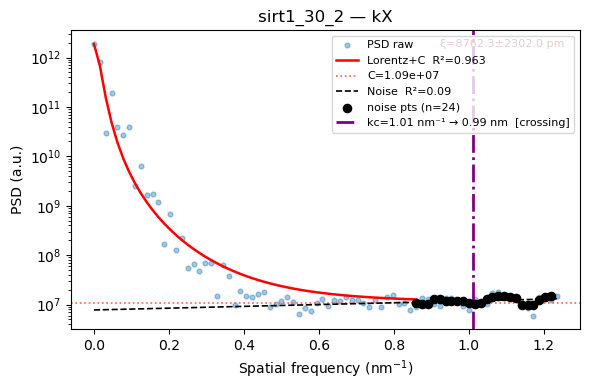

kx [crossing]  kc=1.0105 nm⁻¹  →  0.99 nm


In [7]:
# ── kx  (lateral) ────────────────────────────────────────────────────────────
d_kx  = out["axis_1d"]["kx"]
fit_kx = fit_lorentz_cutoff(d_kx["k"], d_kx["smooth"],
                             kmax_frac=0.7, noise_tail_frac=0.3, noise_kmax_frac=.99, choose_cut="last")
plot_lorentz_fit(out, "kx", fit_kx, title=f"{LABEL} — kX")
if fit_kx["ok"]:
    print(f"kx [{fit_kx['cut_mode']}]  kc={fit_kx['k_cut']:.4f} nm⁻¹  →  {fit_kx['res_cut_nm']:.2f} nm")

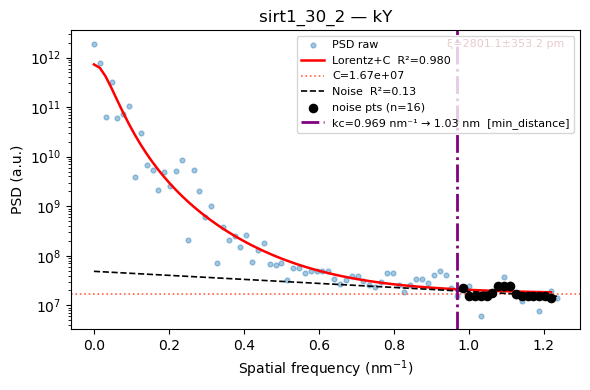

ky [min_distance]  kc=0.9688 nm⁻¹  →  1.03 nm


In [8]:
# ── ky  (lateral) ────────────────────────────────────────────────────────────
d_ky  = out["axis_1d"]["ky"]
fit_ky = fit_lorentz_cutoff(d_ky["k"], d_ky["smooth"],
                             kmax_frac=0.99, noise_tail_frac=0.2, noise_kmax_frac=.99, choose_cut="last")
plot_lorentz_fit(out, "ky", fit_ky, title=f"{LABEL} — kY")
if fit_ky["ok"]:
    print(f"ky [{fit_ky['cut_mode']}]  kc={fit_ky['k_cut']:.4f} nm⁻¹  →  {fit_ky['res_cut_nm']:.2f} nm")

---
## 5 — SIRT 30 / 60 / 90 — PSD comparison

In [9]:
data_path = Path("../Data/PSD_test")
VX = (0.4, 0.4, 0.4)

configs = [
    dict(name="SIRT 30", path=data_path/"sirt1_30_2.tif",
         kmax_frac=.6, noise_tail_frac=0.4, noise_kmax_frac=0.9),
    dict(name="SIRT 60", path=data_path/"sirt1_60_2.tif",
         kmax_frac=.8, noise_tail_frac=0.35, noise_kmax_frac=0.9),
    dict(name="SIRT 90", path=data_path/"sirt1_90_2.tif",
         kmax_frac=1., noise_tail_frac=0.13, noise_kmax_frac=0.99),
]


[AXIS DETECTION]
  kx: decay=1.089e+01 ← tilt (Z)
  ky: decay=6.437e+00
  kz: decay=6.850e+00
  permutation [2, 1, 0]: raw dims → (Z, Y, X)


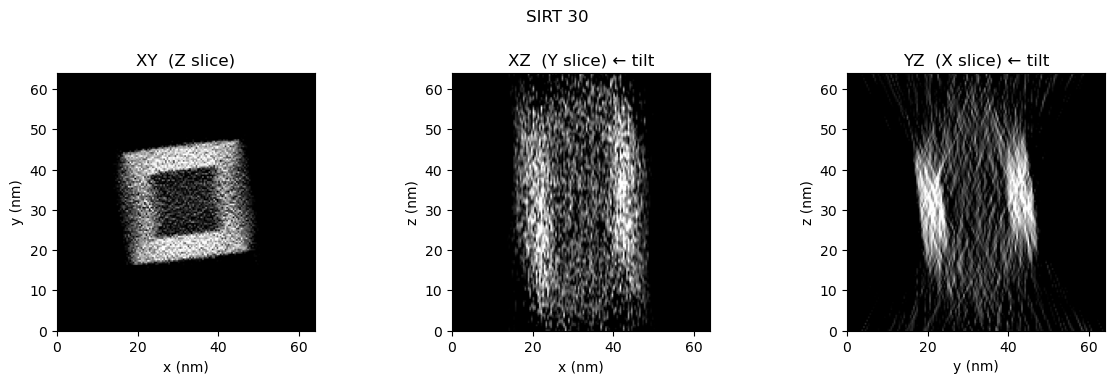

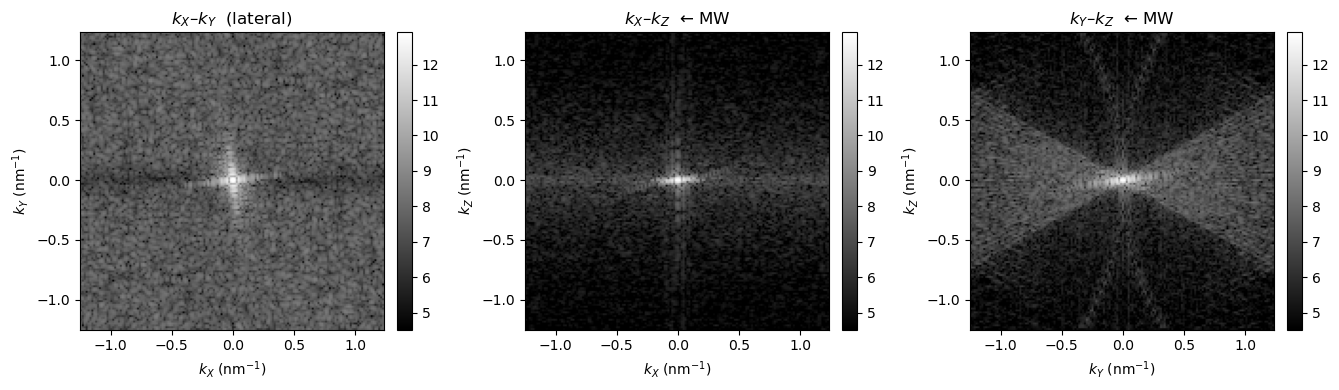

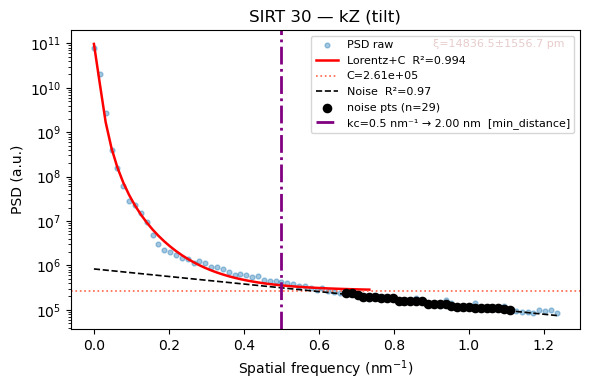

SIRT 30: kc=0.5 nm⁻¹ → 2 nm

[AXIS DETECTION]
  kx: decay=1.123e+01 ← tilt (Z)
  ky: decay=7.926e+00
  kz: decay=6.919e+00
  permutation [2, 0, 1]: raw dims → (Z, Y, X)


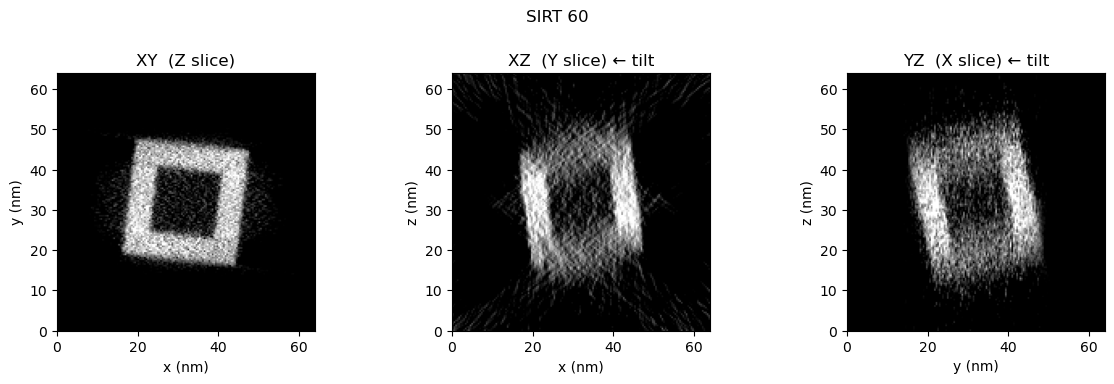

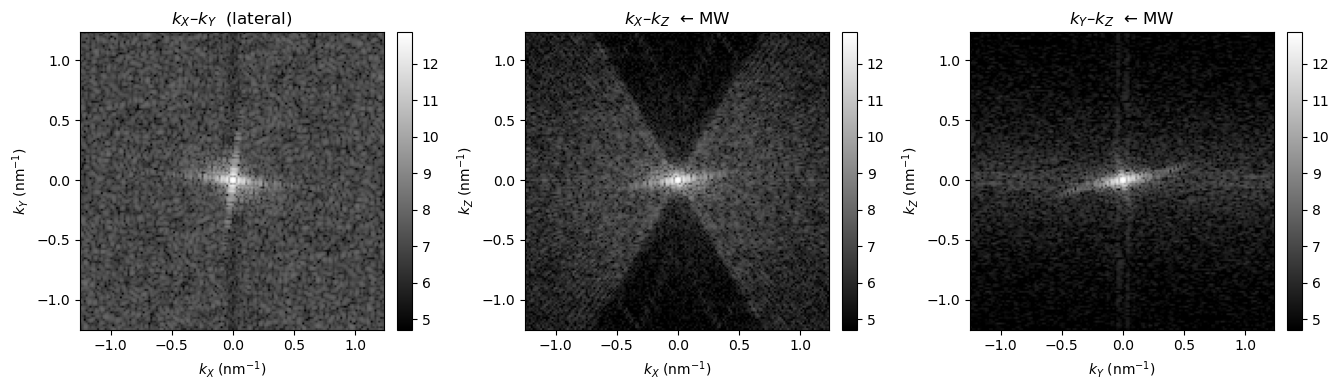

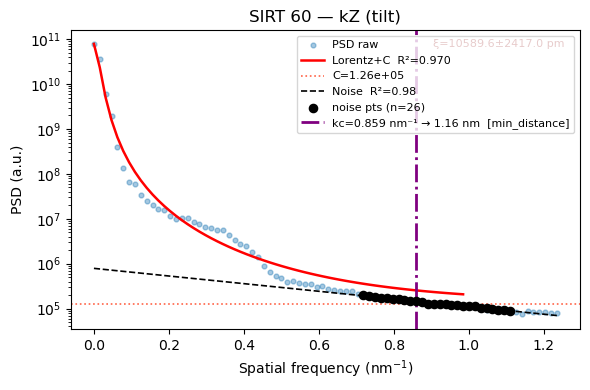

SIRT 60: kc=0.859 nm⁻¹ → 1.16 nm

[AXIS DETECTION]
  kx: decay=8.754e+00
  ky: decay=8.791e+00 ← tilt (Z)
  kz: decay=7.308e+00
  permutation [1, 0, 2]: raw dims → (Z, Y, X)


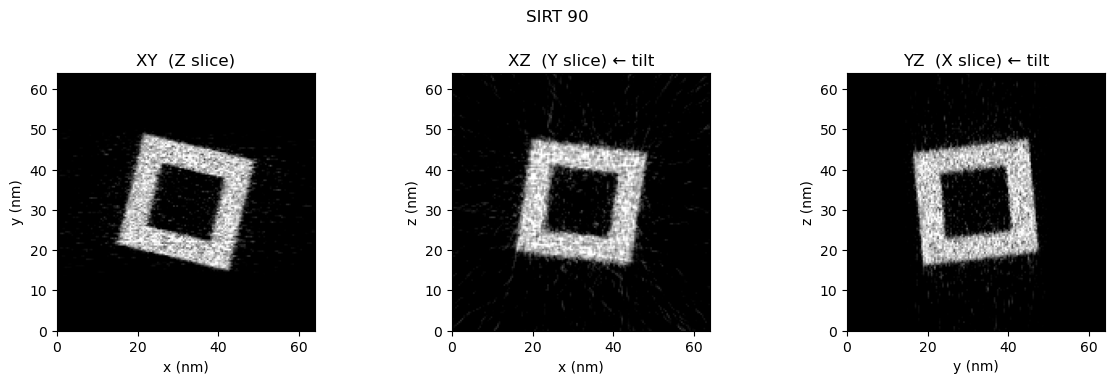

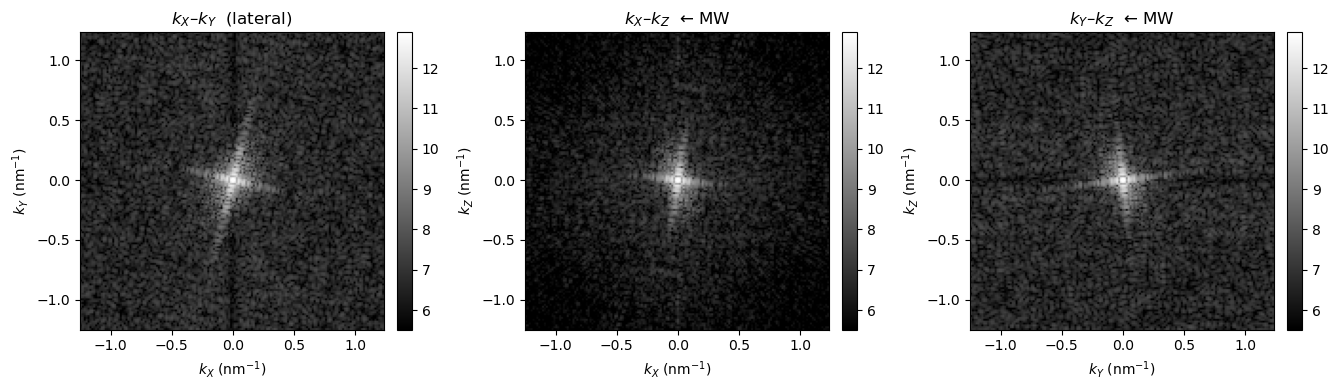

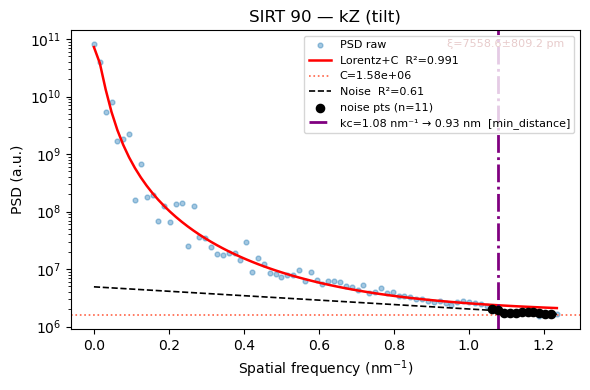

SIRT 90: kc=1.08 nm⁻¹ → 0.928 nm


In [10]:
outs = {}; fits_kz = {}

for cfg in configs:
    name = cfg["name"]
    vol_ = np.clip(np.nan_to_num(imread(str(cfg["path"])).astype(np.float32)), 0, None)

    out_ = compute_psd_analysis(vol_, voxel_nm=VX, band=0.25, smooth_w=5, debug=True)
    outs[name] = out_

    plot_real_space(out_, title=name)
    plot_psd_planes(out_)

    d  = out_["axis_1d"]["kz"]
    fit = fit_lorentz_cutoff(d["k"], d["smooth"],
                              kmax_frac       = cfg["kmax_frac"],
                              noise_tail_frac = cfg["noise_tail_frac"],
                              noise_kmax_frac = cfg["noise_kmax_frac"],
                              choose_cut="last")
    fits_kz[name] = fit
    plot_lorentz_fit(out_, "kz", fit, title=f"{name} — kZ (tilt)")
    if fit.get("ok"):
        print(f"{name}: kc={fit['k_cut']:.3g} nm⁻¹ → {fit['res_cut_nm']:.3g} nm")
    else:
        print(f"{name}: fit failed — {fit.get('reason')}")

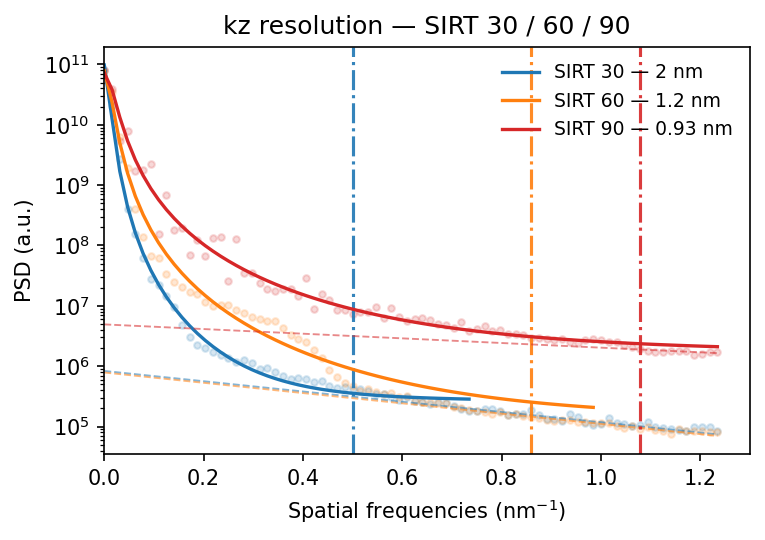

In [11]:
colors = {"SIRT 30": "tab:blue", "SIRT 60": "tab:orange", "SIRT 90": "tab:red"}

fig, ax = plt.subplots(figsize=(5.2, 3.7), dpi=150)

for cfg in configs:
    name = cfg["name"]
    out_ = outs[name]; fit = fits_kz[name]; col = colors[name]
    d    = out_["axis_1d"]["kz"]
    k    = np.asarray(d["k"], float); sm = np.asarray(d["smooth"], float)

    ax.scatter(k, d["raw"], s=10, alpha=0.18, color=col)
    ok = fit.get("ok") and np.isfinite(fit.get("k_cut", np.nan)) and fit["k_cut"] > 0

    if ok:
        lo, hi = fit["fit_range"]
        mf = (k >= lo) & (k <= hi) & np.isfinite(sm) & (sm > 0)
        ax.plot(k[mf], lorentz_psd_C(k[mf], fit["A"], fit["xi"], fit["p"], fit["C"]),
                lw=1.6, color=col, label=f"{name} — {fit['res_cut_nm']:.2g} nm")
        a, b = fit["noise_line"]["a"], fit["noise_line"]["b"]
        ax.plot(k, 10 ** (a + b * k), ls="--", lw=0.9, color=col, alpha=0.55)
        ax.axvline(fit["k_cut"], color=col, ls="-.", lw=1.5, alpha=0.9)
    else:
        ax.plot(k, sm, lw=1.4, color=col, label=f"{name} — no cutoff")

ax.set(yscale="log", xlabel=r"Spatial frequencies (nm$^{-1}$)",
       ylabel="PSD (a.u.)", title="kz resolution — SIRT 30 / 60 / 90", xlim=(0., 1.3))
ax.legend(fontsize=9, frameon=False)
plt.tight_layout(); plt.show()